# GP Returns: Predicted vs Actual (Last Month)

This notebook loads the latest GP artifacts from `return_gp/artifacts`, rebuilds the dataset, and plots predicted vs actual 5-day forward returns for the most recent month of data.


In [7]:
import json
import sys
from pathlib import Path

import gpytorch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import torch

# Resolve paths
root = Path.cwd()
if root.name != "return_gp" and (root / "return_gp").exists():
    base_dir = root / "return_gp"
else:
    base_dir = root

repo_root = base_dir.parent if base_dir.name == "return_gp" else base_dir

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
if str(base_dir) not in sys.path:
    sys.path.append(str(base_dir))

from common import parse_window, walk_forward_splits
import train

artifact_root = base_dir / "artifacts"

ticker_override = None  # set to a ticker symbol to choose a specific artifact folder

candidate_dirs = [
    path
    for path in artifact_root.iterdir()
    if path.is_dir() and (path / "model_state.pt").exists()
]
if not candidate_dirs:
    raise FileNotFoundError(f"No model artifacts found under {artifact_root}")

if ticker_override:
    artifact_dir = artifact_root / ticker_override
    if not (artifact_dir / "model_state.pt").exists():
        raise FileNotFoundError(f"Missing model_state.pt under {artifact_dir}")
else:
    artifact_dir = max(candidate_dirs, key=lambda p: (p / "model_state.pt").stat().st_mtime)

print(f"Using artifacts from: {artifact_dir}")

config = json.loads((artifact_dir / "config.json").read_text(encoding="utf-8"))
scaler = json.loads((artifact_dir / "scaler.json").read_text(encoding="utf-8"))
state = torch.load(artifact_dir / "model_state.pt", map_location="cpu")

ticker = config.get("ticker", artifact_dir.name)
plot_window = "1m"  # last month


Using artifacts from: c:\Users\Tony\marketAnalysis\return_gp\artifacts\AAPL


In [8]:
def apply_scaler(frame, feature_cols, scaler_dict):
    mean = pd.Series(scaler_dict.get("mean", {})).reindex(feature_cols)
    std = pd.Series(scaler_dict.get("std", {})).reindex(feature_cols).replace(0.0, 1.0)

    missing = [col for col in feature_cols if col not in frame.columns or col not in mean.index or col not in std.index]
    if missing:
        raise ValueError(f"Missing feature columns or scaler entries: {missing}")

    return (frame[feature_cols] - mean) / std


# Rebuild dataset (same logic as train.py)
regime_config = config.get("regime_score") or config.get("regime_noise", {})
regime_score_window = regime_config.get("score_window", getattr(train, "REGIME_SCORE_WINDOW", 252))
regime_score_clip = regime_config.get("score_clip", getattr(train, "REGIME_SCORE_CLIP", 4.0))
regime_score_weights = regime_config.get("weights", getattr(train, "REGIME_SCORE_WEIGHTS", {"vix": 0.5, "spy_vol": 0.5}))
regime_enabled = regime_config.get("enabled", True)

end_date = pd.Timestamp.today().normalize()
try:
    start_date = train.compute_start_date(
        end_date,
        config.get("data_years", train.DATA_YEARS),
        config.get("train_window", train.DEFAULT_TRAIN_WINDOW),
        config.get("test_window", train.DEFAULT_TEST_WINDOW),
        regime_score_window,
    )
except TypeError:
    # Backwards compatibility for older train.py signatures.
    start_date = train.compute_start_date(
        end_date,
        config.get("data_years", train.DATA_YEARS),
        config.get("train_window", train.DEFAULT_TRAIN_WINDOW),
        config.get("test_window", train.DEFAULT_TEST_WINDOW),
    )

sector_etf = config.get("sector_etf")
if not sector_etf:
    sector_etf, _, _ = train.resolve_sector_etf(ticker)

history_cache = {}
stock_history = train.fetch_history_cached(ticker, start_date, end_date, history_cache)
sector_history = train.fetch_history_cached(sector_etf, start_date, end_date, history_cache)
gld_history = train.fetch_history_cached(train.TICKER_GOLD, start_date, end_date, history_cache)
spy_history = train.fetch_history_cached(train.TICKER_SPY, start_date, end_date, history_cache)
vix_history = train.fetch_history_cached(train.TICKER_VIX, start_date, end_date, history_cache)

price_stock = train.extract_field(stock_history, "Close", ticker)
volume_stock = train.extract_field(stock_history, "Volume", ticker)
price_sector = train.extract_field(sector_history, "Close", sector_etf)
price_gld = train.extract_field(gld_history, "Close", train.TICKER_GOLD)
price_spy = train.extract_field(spy_history, "Close", train.TICKER_SPY)
price_vix = train.extract_field(vix_history, "Close", train.TICKER_VIX)

features = train.build_features(price_stock, volume_stock, price_sector, price_gld, price_spy, price_vix)
target = train.build_target(price_stock)

price_spy_regime = price_spy.reindex(price_stock.index).ffill().bfill()
price_vix_regime = price_vix.reindex(price_stock.index).ffill().bfill()

if regime_enabled:
    regime_score = train.compute_regime_score(
        price_vix_regime,
        price_spy_regime,
        regime_score_window,
        regime_score_clip,
        regime_score_weights,
    )
else:
    regime_score = pd.Series(0.0, index=price_stock.index, name="regime_score")

features["regime_score"] = regime_score

dataset = features.join([target])
dataset = dataset.dropna()
if dataset.empty:
    raise ValueError("No rows left after feature/target alignment.")

splits = list(
    walk_forward_splits(
        dataset,
        train_window=config.get("train_window", train.DEFAULT_TRAIN_WINDOW),
        test_window=config.get("test_window", train.DEFAULT_TEST_WINDOW),
        embargo=config.get("window_ret", train.WINDOW_RET),
        step=config.get("step_window", train.DEFAULT_STEP_WINDOW),
        min_train_rows=60,
    )
)
if not splits:
    raise ValueError("No walk-forward splits produced; check date range and windows.")

last_split = splits[-1]

feature_cols = state.get("feature_columns")
if not feature_cols:
    raise ValueError("No feature_columns found in model_state.pt.")

train_df = last_split.train.copy()
plot_dataset = dataset.copy()
if "time_index" in feature_cols:
    train_df = train.set_time_index(train_df, last_split.train_start)
    plot_dataset = train.set_time_index(plot_dataset, last_split.train_start)

# Rebuild model using last training window
train_x_df = apply_scaler(train_df, feature_cols, scaler)
train_x = torch.tensor(train_x_df.values, dtype=torch.float32)
train_y = torch.tensor(train_df["target"].values, dtype=torch.float32)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = train.ReturnGPModel(train_x, train_y, likelihood)

model_state = state["model_state_dict"]
try:
    model.load_state_dict(model_state)
except RuntimeError as exc:
    # Handle checkpoints trained with slightly different kernel parameters.
    model_keys = set(model.state_dict().keys())
    filtered_state = {k: v for k, v in model_state.items() if k in model_keys}
    incompat = model.load_state_dict(filtered_state, strict=False)
    dropped = [k for k in model_state.keys() if k not in model_keys]
    print("Warning: model checkpoint did not exactly match current architecture.")
    if dropped:
        print(f"  Ignored keys: {dropped}")
    if incompat.missing_keys:
        print(f"  Missing keys (using defaults): {incompat.missing_keys}")

if "likelihood_state_dict" in state:
    try:
        likelihood.load_state_dict(state["likelihood_state_dict"])
    except RuntimeError as exc:
        print("Warning: likelihood checkpoint did not match current likelihood.")
        print(f"  {exc}")


c:\Users\Tony\marketAnalysis\.venv\Lib\site-packages\gpytorch\likelihoods\noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 0.0001.
  warnings.warn(


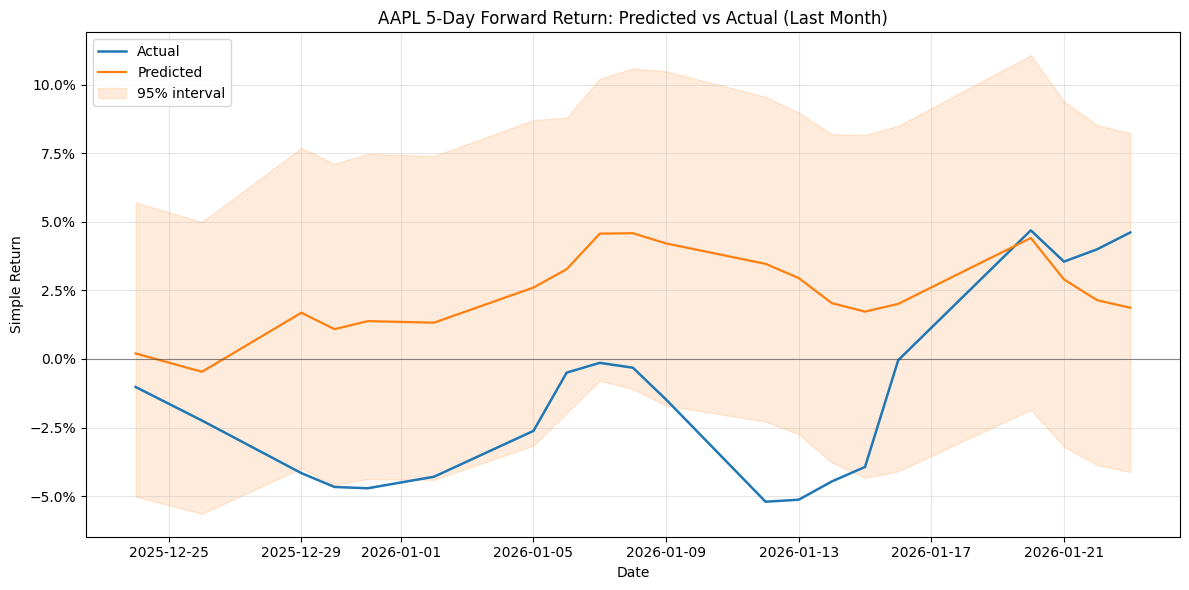

In [9]:
# Predict over the most recent month
window_offset = parse_window(plot_window)
last_date = plot_dataset.index.max()
start_window = last_date - window_offset
plot_df = plot_dataset.loc[(plot_dataset.index > start_window) & (plot_dataset.index <= last_date)]
if plot_df.empty:
    raise ValueError("No data available in the requested window.")

model.eval()
likelihood.eval()

plot_x_df = apply_scaler(plot_df, feature_cols, scaler)
plot_x = torch.tensor(plot_x_df.values, dtype=torch.float32)
with torch.no_grad():
    preds = likelihood(model(plot_x))
    mean = preds.mean.detach().cpu().numpy()
    std = preds.variance.sqrt().detach().cpu().numpy()

actual_log = plot_df["target"].to_numpy()
pred_ret = np.exp(mean) - 1.0
actual_ret = np.exp(actual_log) - 1.0
lower_ret = np.exp(mean - 1.96 * std) - 1.0
upper_ret = np.exp(mean + 1.96 * std) - 1.0

plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, actual_ret, label="Actual", linewidth=1.8, color="#1f77b4")
plt.plot(plot_df.index, pred_ret, label="Predicted", linewidth=1.6, color="#ff7f0e")
plt.fill_between(plot_df.index, lower_ret, upper_ret, color="#ff7f0e", alpha=0.15, label="95% interval")
plt.axhline(0.0, color="#444444", linewidth=0.8, alpha=0.6)

plt.title(f"{ticker} 5-Day Forward Return: Predicted vs Actual (Last Month)")
plt.ylabel("Simple Return")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
